# Graph Representation Learning

## Representation Learning

**Representation learning**, often called **network embedding**, aims to learn a mapping  
$ f: G \rightarrow \mathbb{R}^n$
that transforms a graph or its components from a discrete structure into a continuous, low-dimensional vector space.

The objective is for $f$ to preserve key **local** and **global** structural properties of the graph, so that similar nodes (or subgraphs) remain close in the embedding space.  
These learned vectors can then be used as input features for various downstream machine learning tasks such as classification, clustering, or link prediction.

<img src="figures/chap1_1.png" width="700px" style="display:block; margin:auto;">


## Levels of Graph Representation Learning

Graph representation learning can be performed at different levels of granularity, depending on the specific entity being embedded—whether individual **nodes**, **edges**, or the **entire graph**.  
Each level focuses on capturing structural patterns relevant to its target unit of analysis.

---

## Node-Level Tasks

Node-level tasks aim to predict attributes or labels for individual nodes within a graph.  
These models leverage both node features and the surrounding structural context—i.e., how each node is connected to others—to learn meaningful node representations.

In a social network, for example:
- **Nodes** correspond to users  
- **Edges** represent interactions or relationships  

A node-level task might predict whether a user belongs to a particular community, shares specific interests, or behaves similarly to others.

---

### 🔹 Node2Vec – *Node-Level Embedding Method*

**Node2Vec** generates low-dimensional vector representations for nodes by performing biased random walks on the graph.  
This approach captures both **local neighborhoods** and **broader structural roles**, depending on the bias parameters.

**Example:**  
In a social network, Node2Vec can learn embeddings for users based on network connectivity. These vectors can support downstream tasks such as:
- **Link prediction** (e.g., predicting future friendships)  
- **Role detection** (e.g., identifying influencers or anomalous users)

<img src="figures/chap1_node.gif" width="500px" style="display:block; margin:auto;">
<img src="figures/chap1_2.png" width="300px" style="display:block; margin:auto;">



In [1]:
import numpy as np
np.float_ = np.float64
np.int_ = np.int64

import matplotlib.pyplot as plt
def draw_graph(G, pos_nodes, node_names={}, node_size=50, plot_weight=False):
    nx.draw(G, pos_nodes, with_labels=False, node_size=node_size, edge_color='gray', arrowsize=30)
    
    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.08)
        
    nx.draw_networkx_labels(G, pos_attrs, font_family='serif', font_size=20)
    
    
    if plot_weight:
        pos_attrs = {}
        for node, coords in pos_nodes.items():
            pos_attrs[node] = (coords[0], coords[1] + 0.08)
        
        nx.draw_networkx_labels(G, pos_attrs, font_family='serif', font_size=20)
        edge_labels=dict([((a,b,),d["weight"]) for a,b,d in G.edges(data=True)])
        nx.draw_networkx_edge_labels(G, pos_nodes, edge_labels=edge_labels)
    
    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])

## Node2Vec example

The Node2Vec embedding algorithm is then used in order to map each node of the graph in a vector of two dimensions.

it is easy to see that nodes that have a similar structure are close to each other and are distant from nodes that have dissimilar structures.

c:\Users\sashk\anaconda3\envs\mlgBookPro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sashk\anaconda3\envs\mlgBookPro\lib\site-packages\networkx\drawing\nx_pylab.py:312: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)
Generating walks (CPU: 1): 100%|██████████| 10/10 [00:00<00:00, 84.92it/s]


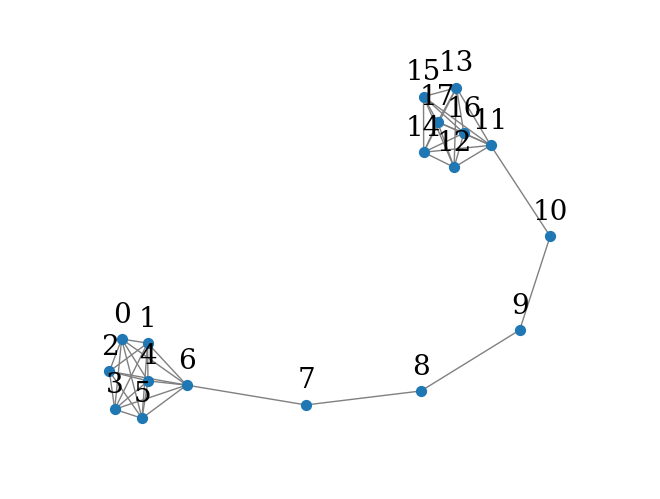

In [2]:
import networkx as nx
from node2vec import Node2Vec

G = nx.barbell_graph(m1=7, m2=4)
draw_graph(G, nx.spring_layout(G))

node2vec = Node2Vec(G, dimensions=2)
model = node2vec.fit(window=5)
#model = node2vec.fit(vector_size=2, window=10, min_count=1, sg=1)

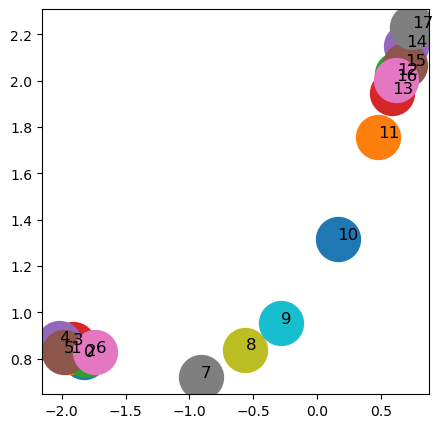

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

for x in G.nodes():
    
    v = model.wv.get_vector(str(x)) #Word vectors include the feature vector (embedding) of each node.
    ax.scatter(v[0],v[1], s=1000)
    ax.annotate(str(x), (v[0],v[1]), fontsize=12)



Graph learning models such as GCN (Graph Convolutional Network), GraphSAGE, or GAT (Graph Attention Network) can capture information from a node’s neighborhood and generate expressive embeddings. These embeddings are then used for classification, clustering, or regression on the nodes.

![nodeLevelExample](../images/chap1_6.png)
ref: https://distill.pub/2021/gnn-intro/


---
## Edge-level tasks
In Edge-level tasks, the goal is to predict a property or label for an edge (i.e., a connection) between two nodes in a graph. These tasks are essential in applications where analyzing or predicting relationships is important.

For instance, in a social network, one might want to
 - predict whether two people are likely to become friends in the future (link prediction), or
 - determine the type of relationship between two individuals (e.g., friendship, collaboration, or competition).

Graph learning models often **compute embeddings for each node, and then combine the embeddings of two connected nodes (using operations such as sum, product, or difference) to obtain a feature vector for the edge**, which can be used for prediction.


### 🔹 Edge2Vec – *Edge-Level Embedding*

Understanding Edge-Level Embedding through an Example:

Consider a graph representing a workplace network, where each node corresponds to an employee. Let's examine two edges:

- Edge A connects a manager to a developer.

- Edge B connects a different manager to a different developer.

Suppose the embeddings for Edge A and Edge B are very similar. This indicates that the relationship type—between a manager and a developer—is structurally or semantically meaningful and consistent across the graph.

✅ Conclusion:
When two edges have similar embeddings, it reflects a similarity in the patterns of interaction between their respective nodes. This can be used to analyze recurring relationship types, detect anomalies, or predict new potential links in the graph.

![nodeLevel](../images/chap1_3.png)


**Edge2Vec** generates embeddings for edges by combining the embeddings of the two endpoint nodes using binary operations such as:
- Hadamard product
- Average
- L1/L2 distance

**Example**:  
In a transaction network, Edge2Vec can be used to represent the interaction between users. These vectors help with:
- Fraud detection
- Anomaly detection in communications

On the left we have an initial graph built from the previous visual scene. On the right is a possible edge-labeling of this graph when some connections were pruned based on the model’s output.

![edgeLevel1](../images/chap1_edge.png)
![edgeLevel2](../images/chap1_edge2.png)

ref: https://distill.pub/2021/gnn-intro/

## Edge2Vec example

Another example on the same graph uses the Edge2Vec algorithm to generate vector representations for the edges. 

Specifically, the HadamardEmbedder is applied to the output of Node2Vec (keyed_vectors = model.wv) to map each edge into a two-dimensional vector space.

In [5]:
from node2vec.edges import HadamardEmbedder
edges_embs = HadamardEmbedder(keyed_vectors=model.wv)

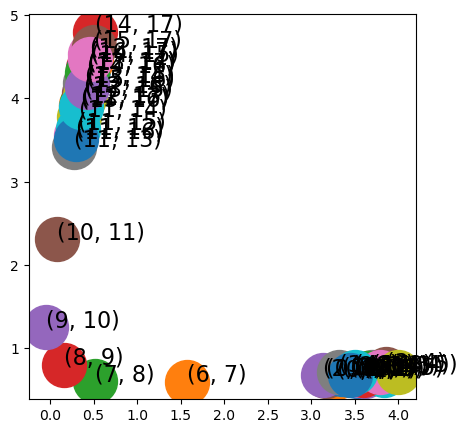

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

for x in G.edges():
    
    v = edges_embs[(str(x[0]), str(x[1]))]
    ax.scatter(v[0],v[1], s=1000)
    ax.annotate(str(x), (v[0],v[1]), fontsize=16)

---
##  Graph-level tasks
In Graph-level tasks, the objective is to predict a global property or label for the entire graph. In these scenarios, each graph is treated as a single data instance.

For example, in the field of chemistry, a molecule can be represented as a graph where nodes are atoms and edges are chemical bonds. A graph-level task could be to predict whether the molecule has medicinal properties or what kind of smell it produces.

In these models, node embeddings are first computed, and then a global pooling operation (such as mean, sum, or attention-based pooling) is used to aggregate node features into a single vector representing the entire graph. This vector is then used for downstream predictions.


### 🔹 Graph2Vec – *Graph-Level Embedding*

**Graph2Vec** provides a single embedding for an entire graph. It treats each graph like a document composed of rooted subgraphs and applies ideas from Doc2Vec to learn its representation.

**Example**:  
In bioinformatics, each graph can represent a molecule. Graph2Vec embeds each molecule into a vector space for:
- Molecular classification
- Similarity search between chemical compounds


![graphLevel](../images/chap1_graph.png)
ref: https://distill.pub/2021/gnn-intro/

## Graph2Vec Example
Finally, we demonstrate a Graph2Vec embedding algorithm, which maps an entire graph to a single vector representation.

In this example:

- We generate 20 Watts-Strogatz graphs with random parameters.

- Each graph is embedded into a 2D vector space using the Graph2Vec algorithm.

- The resulting vectors are plotted in Euclidean space.


![nodeLevel](../images/chap1_4.png)

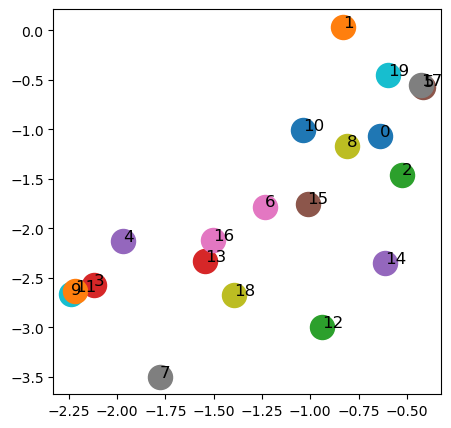

In [15]:
import networkx as nx
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import random
import matplotlib.pyplot as plt

# ------------------------------
# WL feature extractor
# ------------------------------
def wl_features(graph, iterations=2):
    labels = {node: str(graph.degree(node)) for node in graph.nodes()}
    all_features = []

    for it in range(iterations):
        new_labels = {}
        for node in graph.nodes():
            neigh = sorted(labels[n] for n in graph.neighbors(node))
            new_label = labels[node] + "_" + "_".join(neigh)
            new_labels[node] = new_label
        labels = new_labels
        all_features.append(labels.copy())

    return all_features[-1]

# ------------------------------
# SimpleGraph2Vec class
# ------------------------------
class SimpleGraph2Vec:
    def __init__(self, dimensions=16, wl_iterations=2):
        self.dim = dimensions
        self.wl_it = wl_iterations
        self.model = None

    def fit(self, graphs):
        tagged_docs = []
        for i, G in enumerate(graphs):
            feats = wl_features(G, self.wl_it)
            doc = TaggedDocument(words=list(feats.values()), tags=[str(i)])
            tagged_docs.append(doc)

        self.model = Doc2Vec(vector_size=self.dim, min_count=1, epochs=100)
        self.model.build_vocab(tagged_docs)
        self.model.train(tagged_docs, total_examples=len(tagged_docs), epochs=100)

    def get_embedding(self):
        # gensim 3.x fallback
        try:
            return [self.model.dv[str(i)] for i in range(len(self.model.dv))]
        except AttributeError:
            return [self.model.docvecs[str(i)] for i in range(len(self.model.docvecs))]

# ------------------------------
# Generate random graphs
# ------------------------------
n_graphs = 20

def generate_radom():
    n = random.randint(6, 20)
    k = random.randint(3, min(10, n-1))
    p = random.uniform(0, 1)
    return nx.watts_strogatz_graph(n, k, p), [n, k, p]

Gs = [generate_radom() for x in range(n_graphs)]

# ------------------------------
# Train Graph2Vec
# ------------------------------
model = SimpleGraph2Vec(dimensions=2, wl_iterations=3)
model.fit([x[0] for x in Gs])
embeddings = model.get_embedding()

# ------------------------------
# Plot embeddings
# ------------------------------
fig, ax = plt.subplots(figsize=(5,5))
for i, vec in enumerate(embeddings):
    ax.scatter(vec[0], vec[1], s=300)
    ax.annotate(str(i), (vec[0], vec[1]), fontsize=12)

plt.show()


---

### Summary

| Algorithm   | Level       | Output          | Example Use Case             |
|-------------|-------------|------------------|-------------------------------|
| Node2Vec    | Node-level  | Vector per node  | User classification           |
| Edge2Vec    | Edge-level  | Vector per edge  | Link prediction, fraud detection |
| Graph2Vec   | Graph-level | Vector per graph | Molecule classification       |